In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **1. Carga  y limpieza de datos**

In [4]:
df= pd.read_csv('../Data/Historical Product Demand.csv')


In [5]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


- Las fechas estan en formato incorrecto
- Existen nulos en card (?)

## Revision datos nulos

In [7]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [8]:
print(f'La cantidad de nulos es {np.max(df.isnull().sum().values)} y el dataframe tiene {df.shape[0]}')

La cantidad de nulos es 11239 y el dataframe tiene 1048575


- En este caso debido a que la cantidad de nulos que representa casi un 1.1 % del total de los datos es correcto eliminarlos

In [9]:
df.dropna(subset=['Date'], inplace=True)

- Existen bastantes nulos los que eliminaremos
- Además también existen otros carácteres que no son números

# **2.  Análisis exploratorio (EDA)**

## Revisando las variables categoricas y numericas si existen problemas

In [10]:
for col in df[['Product_Code', 'Warehouse', 'Order_Demand']].columns:

    print(df[col].unique)

<bound method Series.unique of 0          Product_0993
1          Product_0979
2          Product_0979
3          Product_0979
4          Product_0979
               ...     
1048570    Product_1791
1048571    Product_1974
1048572    Product_1787
1048573    Product_0901
1048574    Product_0704
Name: Product_Code, Length: 1037336, dtype: object>
<bound method Series.unique of 0          Whse_J
1          Whse_J
2          Whse_J
3          Whse_J
4          Whse_J
            ...  
1048570    Whse_J
1048571    Whse_J
1048572    Whse_J
1048573    Whse_J
1048574    Whse_J
Name: Warehouse, Length: 1037336, dtype: object>
<bound method Series.unique of 0           100 
1           500 
2           500 
3           500 
4           500 
           ...  
1048570    1000 
1048571       1 
1048572    2500 
1048573      50 
1048574       4 
Name: Order_Demand, Length: 1037336, dtype: object>


- La única columna que se ve con problemas seria `Order_demand` la que no es numérica y además tiene carácteres como paréntesis

### Eliminando los datos que no sean numeros de la columna order_demand

In [11]:
df['Order_Demand'] = df['Order_Demand'].str.replace(r'[^0-9]', '', regex=True).astype(int)


- Aprovechamos de después de sacar todos los datos no numericos convertir a integer, si está bien entonces no deberia tirar error.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1037336 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1037336 non-null  object
 1   Warehouse         1037336 non-null  object
 2   Product_Category  1037336 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1037336 non-null  int32 
dtypes: int32(1), object(4)
memory usage: 43.5+ MB


## Convirtiendo Date a datetime

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.set_index('Date', inplace=True)

## Revisando los estadisticos

In [15]:
df.describe().round(2)

,Order_Demand
count,1037336.00
mean,4949.38
std,29073.44
min,0.00
25%,20.00
50%,300.00
75%,2000.00
max,4000000.00


- Existen datos donde no hay ordenes lo que sugiere que fueron dias donde no se vendió nada.
- El 75 % de los datos se encuentra por debajo de 2000 ordenes pero el valor máximo es de 4000000 lo que es 1999 veces más grande
- En este punto no podriamos ver bien la distribucion ya que por este valor la diferencia de escalas no dejara revisar bien su distribución
     

## Revisando los valores de Order_Demand

C:\Users\kev_g\AppData\Local\Temp\ipykernel_32376\819333884.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Order_Demand'], palette='pastel')


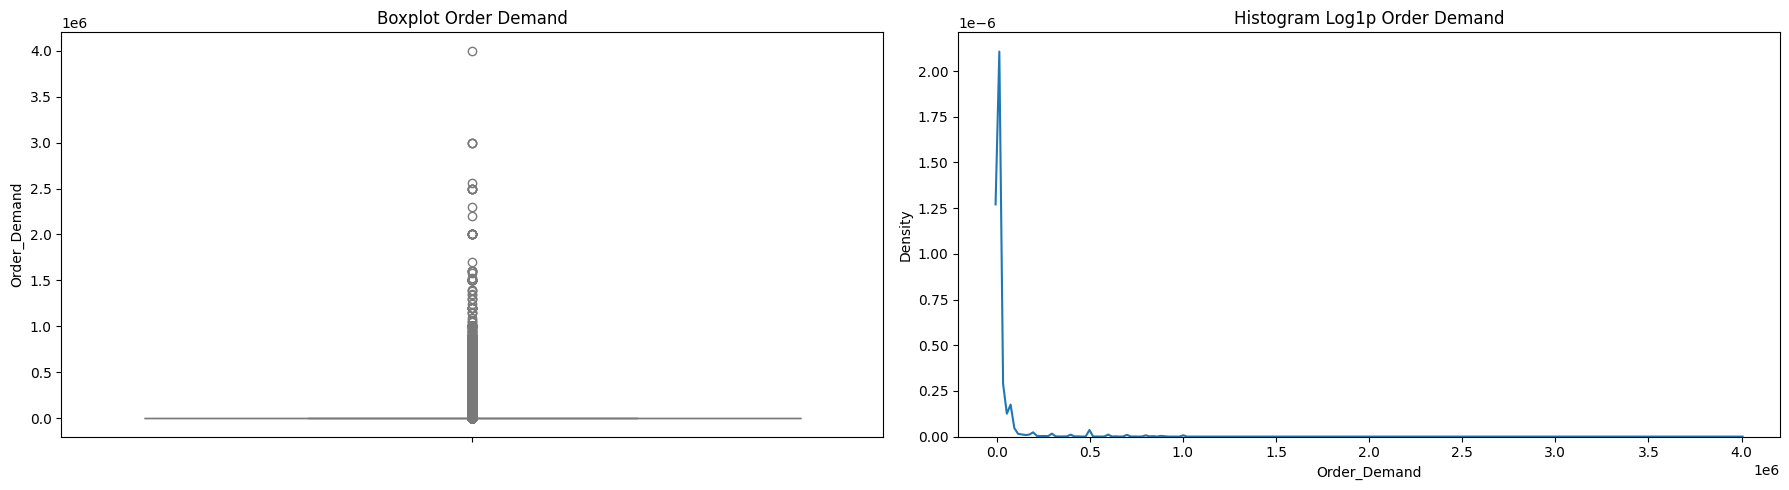

In [35]:
plt.figure(figsize=(18, 5)) 
plt.subplot(121)
sns.boxplot(df['Order_Demand'], palette='pastel')
plt.title('Boxplot Order Demand')

plt.subplot(122)
sns.kdeplot(df['Order_Demand'])
plt.title('Histogram Log1p Order Demand')


plt.tight_layout()
plt.show()

- El gráfico biene a confirmar lo que vimos anteriormente

C:\Users\kev_g\AppData\Local\Temp\ipykernel_32376\1993557964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(np.log1p(df['Order_Demand']), palette='pastel')


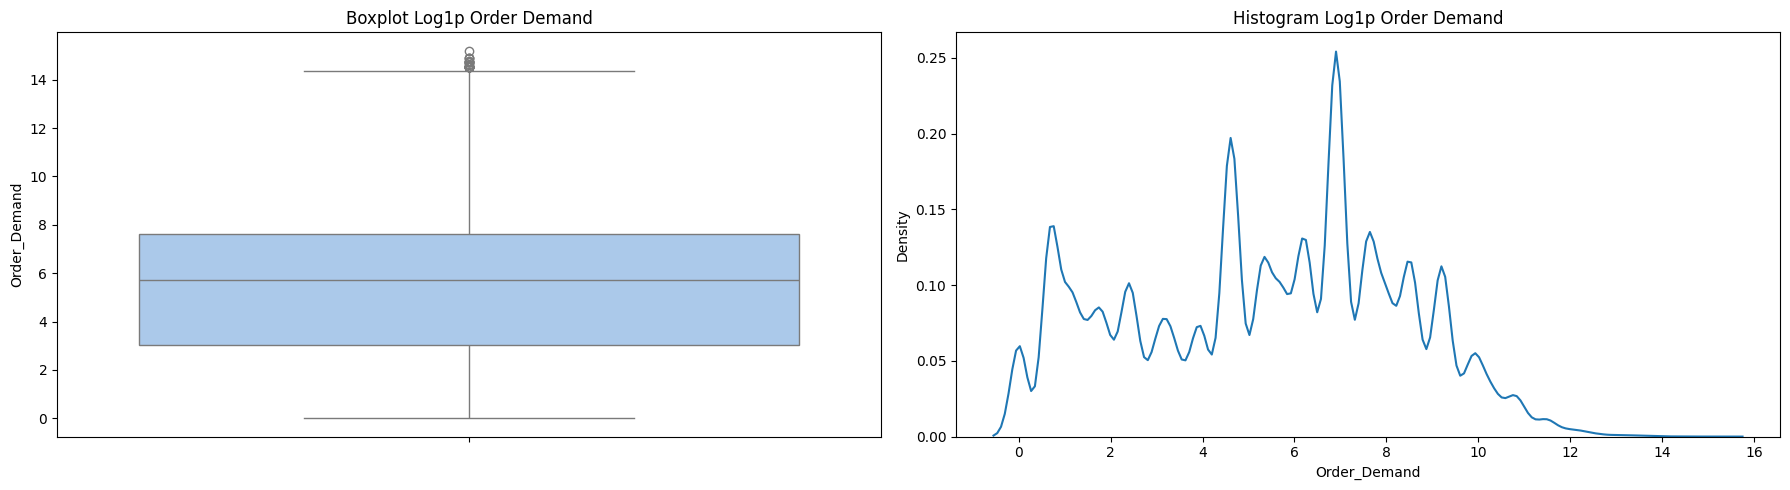

In [36]:
plt.figure(figsize=(18, 5)) 

plt.subplot(121)
sns.boxplot(np.log1p(df['Order_Demand']), palette='pastel')
plt.title('Boxplot Log1p Order Demand')

plt.subplot(122)
sns.kdeplot(np.log1p(df['Order_Demand']))
plt.title('Histogram Log1p Order Demand')

plt.tight_layout()
plt.show()


In [ ]:
df['Order_Demand_log'] = np.log1p(df['Order_Demand'])   

- Al parecer los valores grandes no son valores mal ingresados ya que existen bastantes valores después del cuartil 3.

<Axes: title={'center': 'Demanda vs tiempo'}, xlabel='Date'>

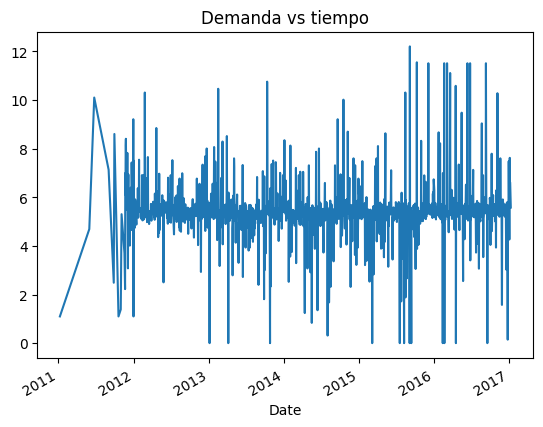

In [48]:
df.groupby(df.index)['Order_Demand_log'].mean().plot(kind='line', title='Demanda vs tiempo')

- Lo primero que se observa que antes desde el 2011 hasta principio del 2012 los datos no son representativos de la mayor parte de nuestro universo

- Teniendo en consideración este gráfico modelare desde el 2012 hasta el 2016

In [133]:
y = df['Order_Demand_log'].resample('W-MON').mean()




In [134]:
y = y.ffill()

- Considerando que los datos no se ven prometedores con el valor máximo, tomaremos desde finales del 2019 en adelante

In [135]:
y = y[(y.index.year >2012)]


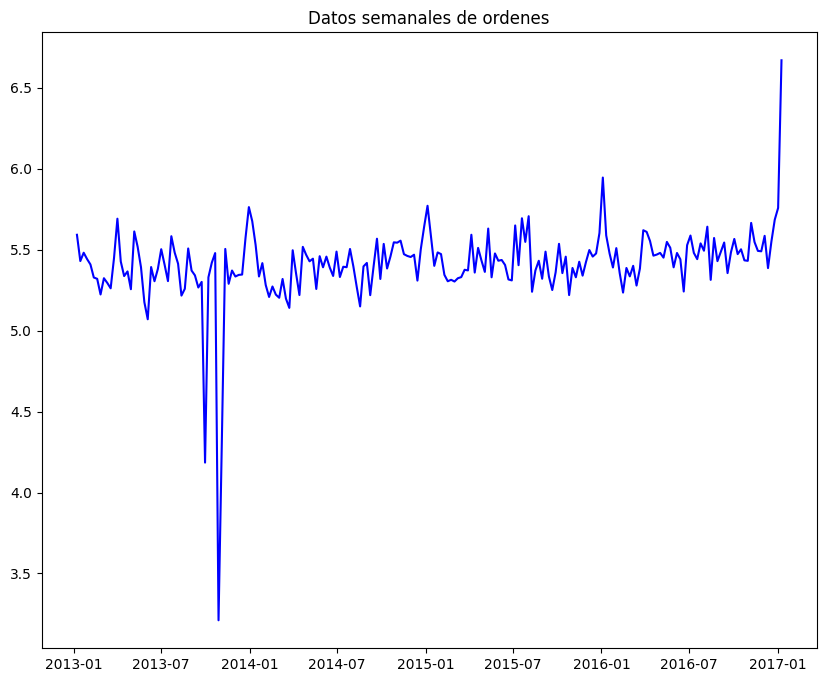

In [136]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.title('Datos semanales de ordenes')
plt.show()

- Lo más interesante de nuestros datos es que estos se mantienen dentro de un rango en general constante con algunos picos como los ubicados entre el 2013 y 2014. Además del final del 2017 donde sube bastante.
- El siguiente paso será revisar cuantos datos se encuentran bajo los 4.75 y sobre los 6.0

In [138]:
y[(y<=4.75) | (y>=6.3)]

Date
2013-09-30    4.185011
2013-10-28    3.210743
2013-11-04    4.337130
2017-01-09    6.670803
Name: Order_Demand_log, dtype: float64

- Solo existen 4 puntos que se encuentran fuera de la tendencia general... por lo que estos pueden ser o outliers o datos mal ingresados... nunca lo sabremos.
- Lo que sabemos ahora que estos puntos los podriamos eliminar o interpolar o reemplazar

In [139]:
y_copia = y.copy()

y[(y < 4.60)  | (y>=6.3)] = np.nan


In [140]:

y = y.interpolate(method='linear')

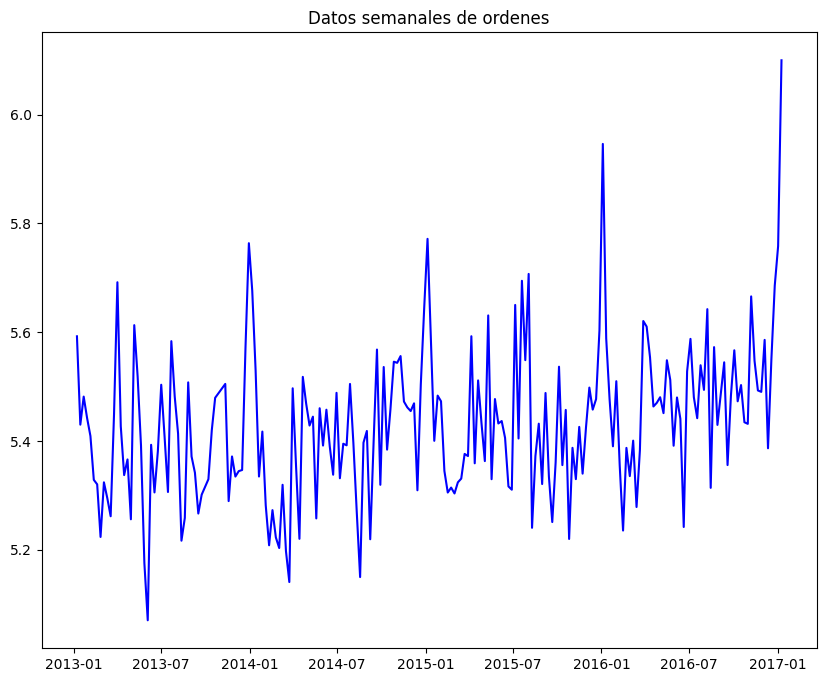

In [153]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.title('Datos semanales de ordenes')
plt.show()

- El problema de hacer esto es que al reemplazar tambien el valor del 2017 subestima el crecimiento de esta fecha que esta acorde a la tendencia de los datos
- Por esta razon voy a dejar al dato sin reemplazar

In [150]:
y.sort_values(ascending=False)

Date
2016-01-04    5.946235
2015-01-05    5.771758
2013-12-30    5.763767
2017-01-09    5.758504
2017-01-02    5.758504
                ...   
2014-03-17    5.197869
2013-05-27    5.175905
2014-08-18    5.150052
2014-03-24    5.140918
2013-06-03    5.070622
Name: Order_Demand_log, Length: 210, dtype: float64

In [152]:
y[y.index=='2017-01-09'] = 6.1

# **FORECASTING MODELAJE**

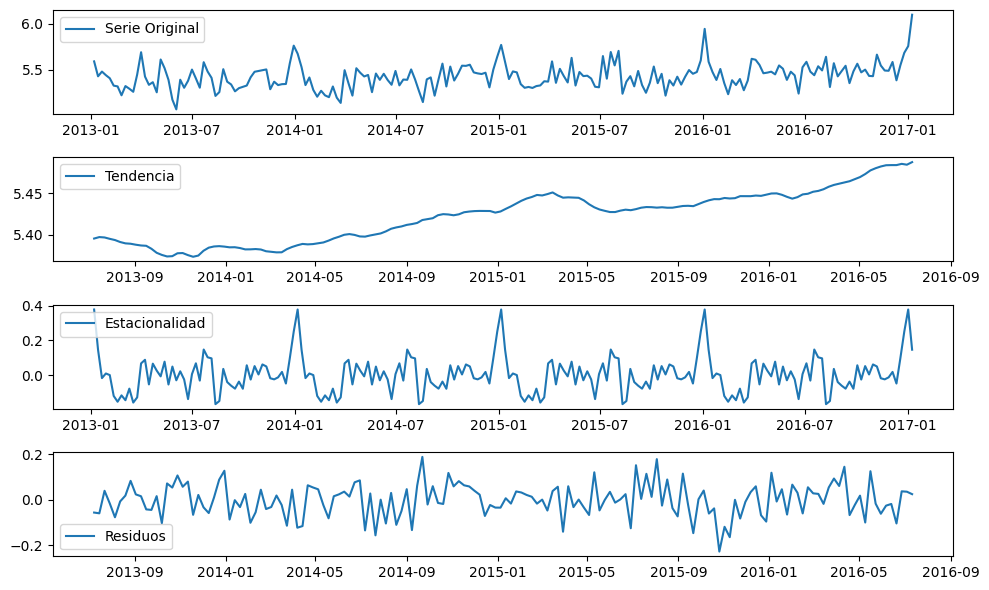

In [154]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(y, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()
plt.tight_layout()
plt.show()

- Lo primero que es notorio es que la tendencia es al alza sostenida desde 2014-01 hasta el 2015-04 donde disminuye y alcanza una meseta que progresivamente sigue aumentando hasta al final de nuestros datos
- Cada año se repite un patron ciclico en los datos donde siempre a principios de año hay un peak muy marcado de ordenes, lo que puede estar ligado algun tipo de promoción a fin de año. Posterior a esto bajan significativamente las ventas volviendo a tener un repunte significativamente mayor que el de principio de año y aún más variable. Considerando esto podemos considerar que cada 52 semanas hay un ciclo.

- Los residuos se encuentran bastante variables pero en general no dan signos más contundentes de seguir patrones

## **¿ Es la serie Estacionaria ?**

In [155]:
from statsmodels.tsa.stattools import adfuller

# Realizar el test de Dickey-Fuller
result = adfuller(y.values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -6.0041649844955
p-value: 1.6304741192550954e-07
Critical Values: {'1%': -3.4621857592784546, '5%': -2.875537986778846, '10%': -2.574231080806213}


- Partimos de la $h_{o}:$ La serie no es estacionaria. Claramente en nuestro caso **rechazamos la hipotesis nula** y nuestra serie es *estacionaria*

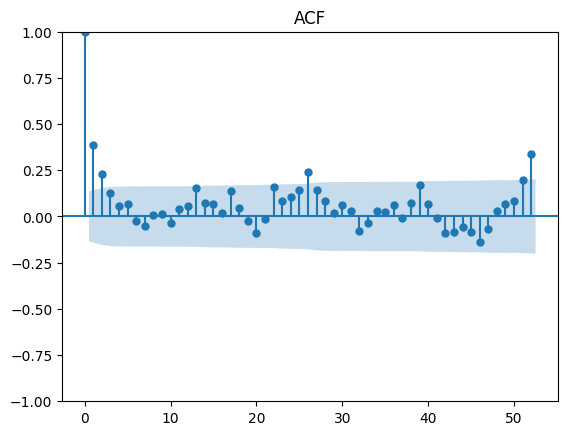

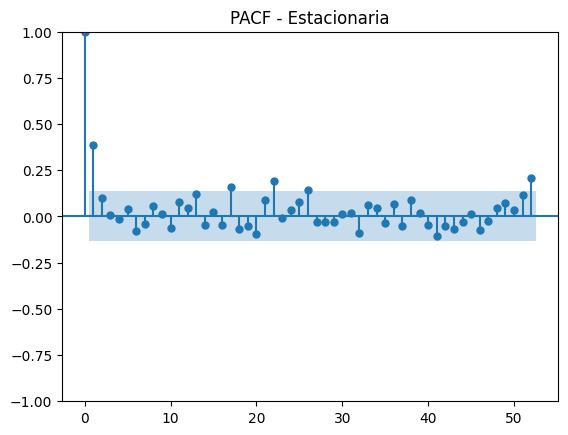

In [156]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(y,  title="ACF", lags='52')
plt.show()
plot_pacf(y, title="PACF - Estacionaria", lags='52')
plt.show()

Tanto `ACF`(q) como `PACF`(p) muestra en sus LAGS alta correlaciones en diferentes momentos a lo largo del eje. La no existencia de decaimiento gradual en ninguno de los dos graficos además de en el gráfico anterior en su estacionaridad me hace concluir que necesitamos un modelo SARIMA debido tambien a que se ve claramente que existen patrones en ambos gráficos. Esto deberá incluir tanto diferenciacion en AR, MA, y en la componente Seasonal. 

Una diferenciacion anual en este caso en 52 semanas parece adecuada para intentar que los lags no se encuentren tan correlacionados con el primer lag. Ademas considerar que en 



**d**: Si bien nuestro test dice que la serie es estacionaria esto no implica que no existan correlaciones complejas o que la estacionalidad esté completamente removida por lo que hacer d=1 parece ser una buena idea. Otra razon para esto es reducir la varianza de la serie, simplificar AR/MA debido a que correlaciones persistentes generan ordenes de p y q más alto y al aplicar diferenciación nos aseguramos capar esto.

In [ ]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(y, order=(1, 0, 1), seasonal_order= (0, 1, 0, 52))
results = model.fit()
print(results.summary())

# Pronóstico para los próximos 'n' pasos
n_pronostico = 52 # Ejemplo: pronóstico para las próximas 52 semanas
pronostico_sarima = results.get_forecast(steps=n_pronostico)
pronostico_intervalo = pronostico_sarima.conf_int()


                                      SARIMAX Results                                      
Dep. Variable:                    Order_Demand_log   No. Observations:                  210
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 52)   Log Likelihood                  87.939
Date:                             Mon, 31 Mar 2025   AIC                           -169.879
Time:                                     18:04:09   BIC                           -160.691
Sample:                                 01-07-2013   HQIC                          -166.147
                                      - 01-09-2017                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9522      0.048     19.771      0.000       0.858       1.047
ma.L1         -0.8674      

:pushpin: <center><B><U>INTERPRETACIÓN</U></B></center>

### **Ljung-Box**:

Mide si los residuos están o no correlacionados (patrones que el modelo no ha capturado)

$H_{0}$: **los residuos NO están autocorrelacionados**. En nuestro caso la **Prob(Q)** es de 0.18 que es mayor que nuestro p_value no tenemos información suficiente para rechazar la hipotesis nula por lo que la aceptamos

:white_check_mark: Residuos no correlacionados

### **Jarque-Bera (JB)**

Permite conocer si los residuos tienen una distribución normal (necesario para que nuestros residuos sean ruido blanco)


$H_{0}$: **Los residuos son normalmente distribuidos.**.

En nuestro caso **Prob(JB)** $<$ **p_value** por lo que **rechazamos** la hipotesis nula

:warning: Los residuos no estan normalmente distribuidos

### **Heteroskedasticity (H)**

Evalua si la varianza de los residuos es constante 

$H_{0}$: **Varianza constante**.

En nuestro caso **Prob(H)** $>$ **p_value** por lo que la varianza de los residuos es constante


:white_check_mark: La varianza de nuestros residuos son costante


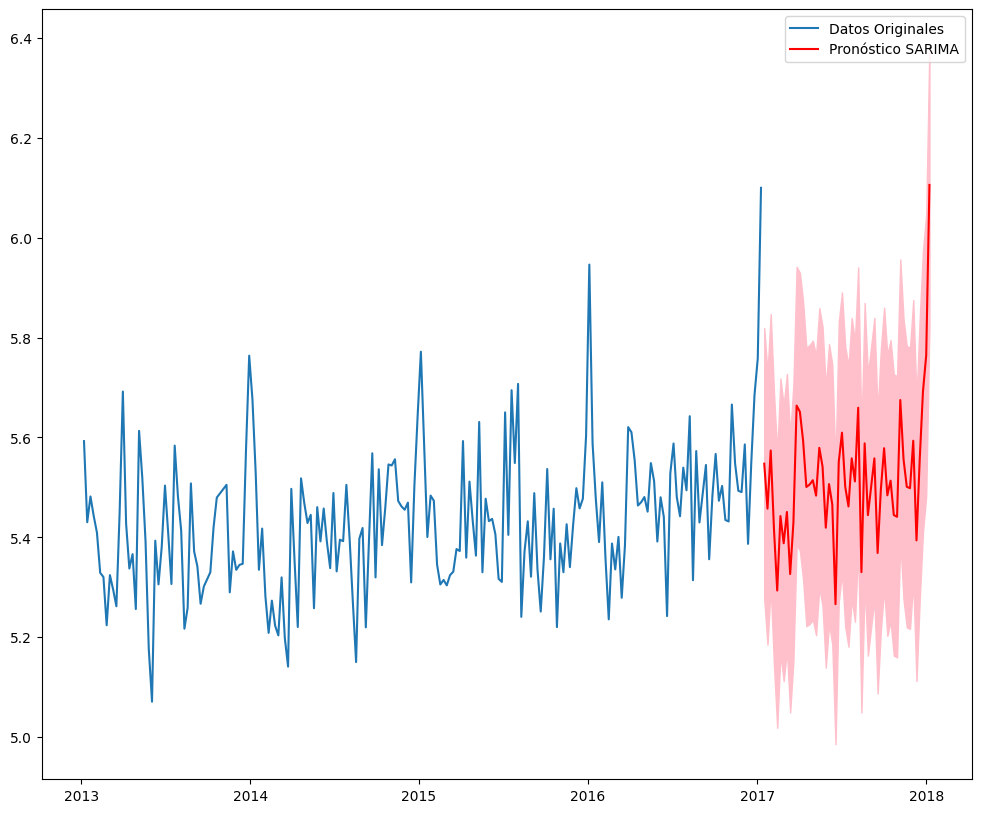

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
plt.plot(y, label='Datos Originales')
plt.plot(pronostico_sarima.predicted_mean, color='red', label='Pronóstico SARIMA')
plt.fill_between(pronostico_intervalo.index, pronostico_intervalo.iloc[:, 0], pronostico_intervalo.iloc[:, 1], color='pink')
plt.title('Forescast')
plt.legend()
plt.show()

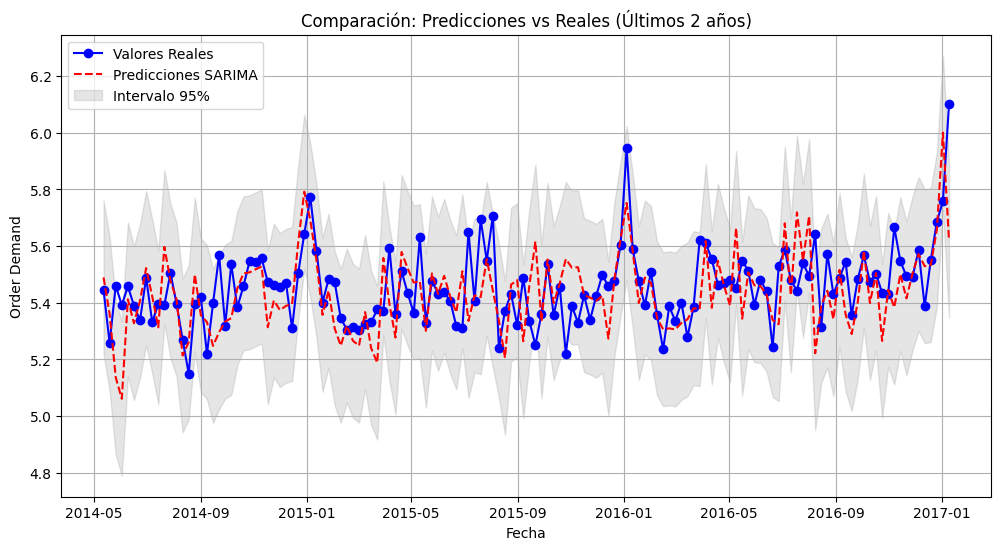

MAE: 229.86
RMSE: 232.48


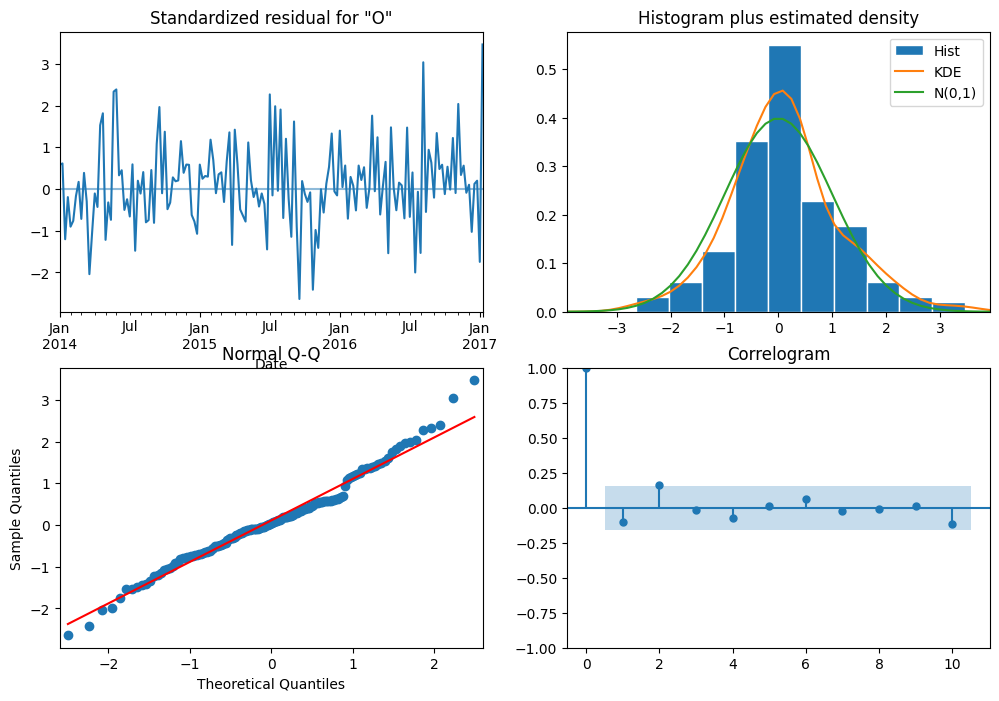

In [191]:
# Definir el rango de los últimos 2 años (ajusta las fechas según tus datos)
start_date = y.index[70]  # Fecha inicial de los últimos 2 años
end_date = y.index[-1]  # Última fecha disponible

# Obtener predicciones dentro de la muestra para el rango deseado
predictions = results.get_prediction(
    start=start_date, 
    end=end_date, 
    dynamic=False  # Predicciones estáticas (no recursivas)
)

# Extraer valores predichos y reales
predichos = predictions.predicted_mean
reales = y.loc[start_date:end_date]
intervalos = predictions.conf_int()


plt.figure(figsize=(12, 6))

# Graficar datos reales
plt.plot(reales, label='Valores Reales', color='blue', marker='o')

# Graficar predicciones
plt.plot(predichos, label='Predicciones SARIMA', color='red', linestyle='--')

# Rellenar intervalo de confianza
plt.fill_between(
    intervalos.index,
    intervalos.iloc[:, 0],
    intervalos.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)

plt.title('Comparación: Predicciones vs Reales (Últimos 2 años)')
plt.xlabel('Fecha')
plt.ylabel('Order Demand')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calcular MAE y RMSE

reales =  np.expm1(reales)

mae = mean_absolute_error(reales, predichos)
rmse = np.sqrt(mean_squared_error(reales, predichos))
# 
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')



results.plot_diagnostics(figsize=(12, 8))
plt.show()


- En general los residuos fluctuan cercano al cero lo que es bueno. No hay un patron claro de estacionalidad, aunque está claro que hay periodos muy volátiles.
- El histograma se ve que se asemeja bastante a la de una distribución normal unque con una inclinación de su moda a la derecha.
- La mayor parte de los puntos se alinea a la linea teórica aunque cerca de los cuantiles -2 y de 1 añ 2 estos se van separando progresivamente. Esto sugiere que las colas de la distribución pueden ser más pesadas o ligeras que una distribución normal
- En el LAG 2 y 5 se observan valores significativos lo que nos permite observar que aún existe una autocorrelación significativa en esos lags.

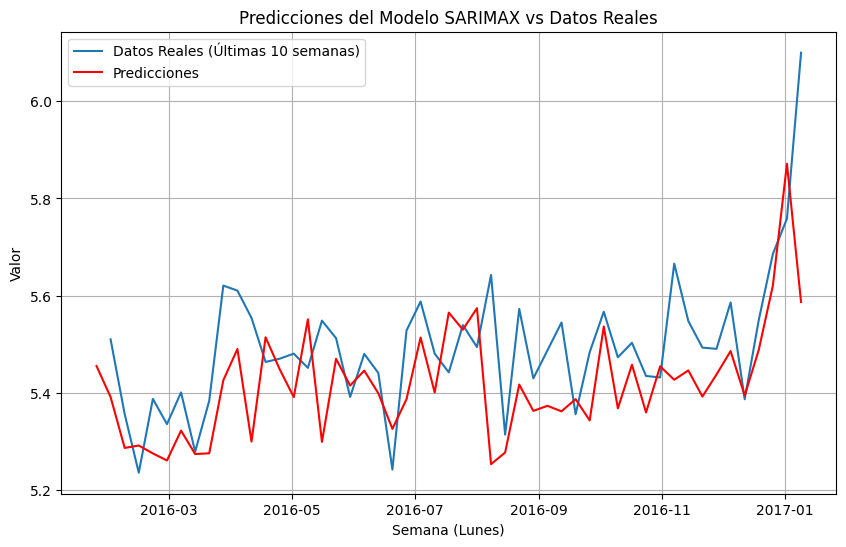

In [186]:
import statsmodels.api as sm
from pandas.tseries.offsets import DateOffset
import matplotlib.pyplot as plt

# Supongamos que ya tienes tu y_transformed_series con un índice de fechas (todos los lunes)

model = sm.tsa.SARIMAX(y, order=(0, 0, 0), seasonal_order= (1, 1, 0, 52))
results = model.fit()

last_date = y.index[-1]
start_date_predict = last_date - DateOffset(weeks=50) # Esta es la forma correcta

predictions = results.predict(start=start_date_predict, end=last_date)

# Graficar las predicciones vs los datos reales
plt.figure(figsize=(10, 6))
plt.plot(y[-50:], label='Datos Reales (Últimas 10 semanas)')
plt.plot(predictions, color='red', label='Predicciones')
plt.xlabel('Semana (Lunes)')
plt.ylabel('Valor')
plt.title('Predicciones del Modelo SARIMAX vs Datos Reales')
plt.legend()
plt.grid(True)
plt.show()

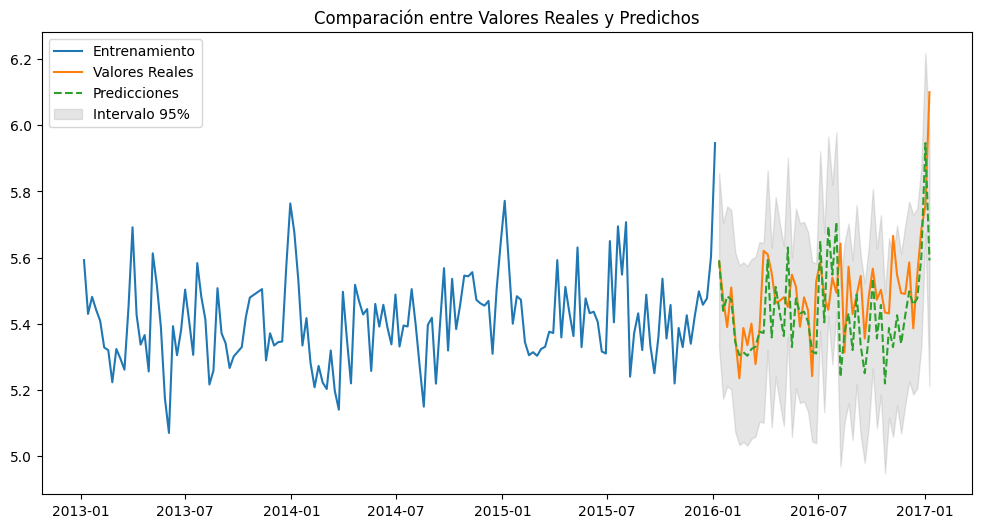

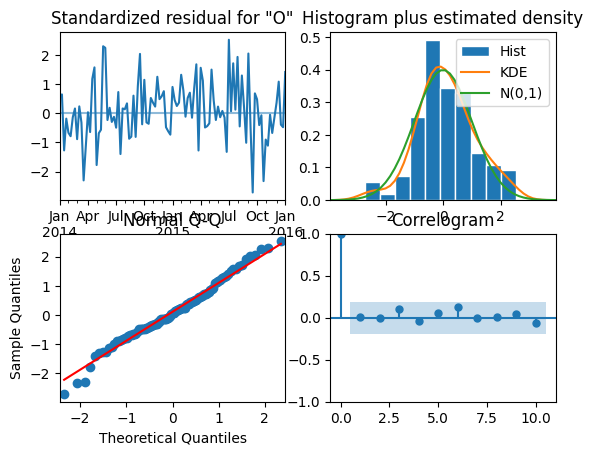

In [187]:
from scipy.special import inv_boxcox
y = y
midpoint = len(y)*3//4
train = y.iloc[:midpoint]
test = y.iloc[midpoint:]

model = sm.tsa.SARIMAX(train, order=(0, 0, 2), seasonal_order=(0, 1, 0, 52))
results = model.fit()

# Obtener predicciones para el período de prueba
forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean

import matplotlib.pyplot as plt

intervalos = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Valores Reales')
plt.plot(test.index, forecast_mean, label='Predicciones', linestyle='--')
plt.title('Comparación entre Valores Reales y Predichos')
plt.fill_between(
    intervalos.index,
    intervalos.iloc[:, 0],
    intervalos.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)
plt.legend()
plt.show()



results.plot_diagnostics()
plt.show()



In [185]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=True,
    m=52,  # frecuencia semanal
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\d

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=-114.656, Time=0.30 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=-123.809, Time=20.74 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,0,1)(1,1,0)[52] intercept   : AIC=-123.549, Time=9.72 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(1,1,0)[52] intercept   : AIC=-122.987, Time=23.55 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(1,1,0)[52]             : AIC=-122.921, Time=4.98 sec

Best model:  ARIMA(0,0,0)(1,1,0)[52] intercept
Total fit time: 315.453 seconds
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Observations:                  157
Model:             SARIMAX(1, 1, 0, 52)   Log Likelihood                  65.243
Date:                  Mon, 31 Mar 2025   AIC                           -124.486
Time:                          18:00:12   BIC                           -116.525
Sample:                      01-07-2013   HQIC                          -121.260
                           - 01-04-2016                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0277      0.014      1.943    

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
errors = []

for train_index, test_index in tscv.split(y_transformed_series):
    train, test = y_transformed_series.iloc[train_index], y_transformed_series.iloc[test_index]
    model = sm.tsa.SARIMAX(train, order=(0,0,2), seasonal_order=(0,0,0,52))
    results = model.fit(disp=False)
    forecast = results.get_forecast(steps=len(test)).predicted_mean
    forecast_inv = inv_boxcox(forecast, lambda_)
    test_inv = inv_boxcox(test, lambda_)
    rmse = np.sqrt(mean_squared_error(test_inv, forecast_inv))
    errors.append(rmse)

print("Promedio RMSE:", np.mean(errors))


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters

Promedio RMSE: 5227.898084902664


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


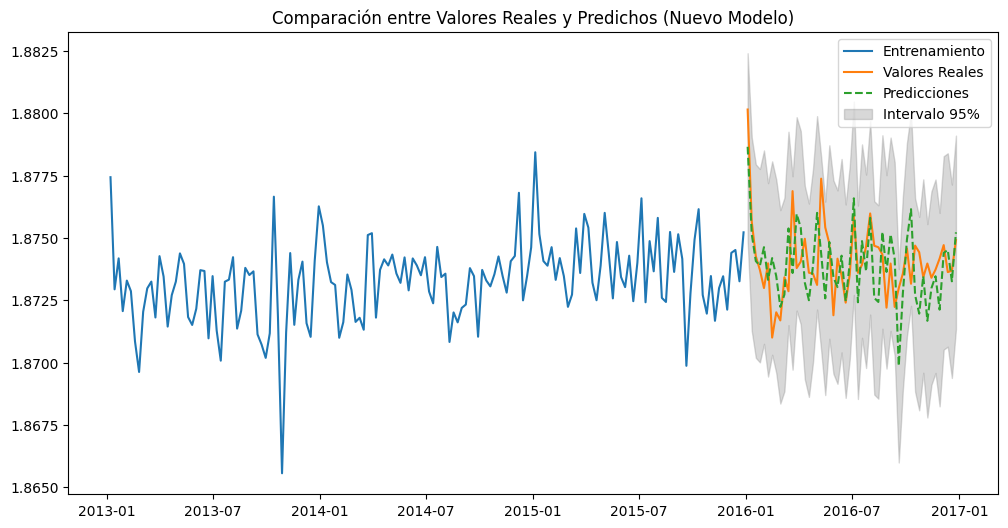

In [ ]:
# --- Dividir en entrenamiento y prueba ---
midpoint = len(y_transformed_series) * 3 // 4
train = y_transformed_series.iloc[:midpoint]
test = y_transformed_series.iloc[midpoint:]

# --- Ajustar nuevo modelo SARIMA ---
model = sm.tsa.SARIMAX(train, order=(0, 0, 1), seasonal_order=(0, 1, 0, 52))
results = model.fit()

# --- Predicciones ---
forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# --- Gráfico ---
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Valores Reales')
plt.plot(test.index, forecast_mean, label='Predicciones', linestyle='--')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3, label='Intervalo 95%')
plt.title('Comparación entre Valores Reales y Predichos (Nuevo Modelo)')
plt.legend()
plt.show()

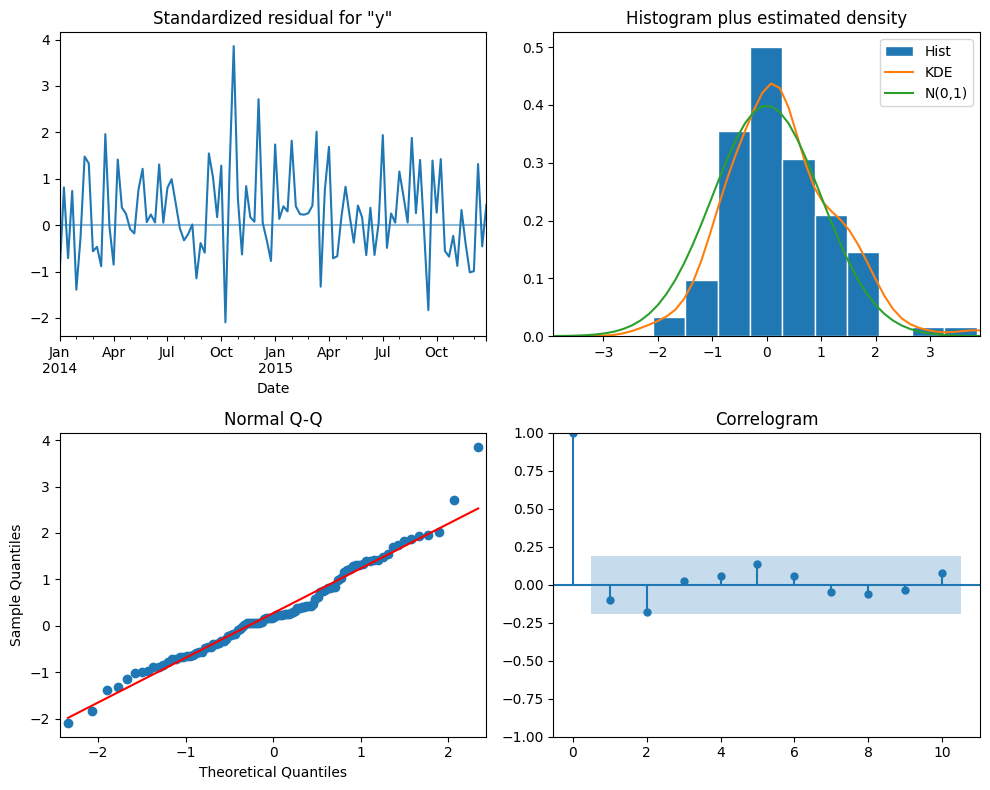

In [ ]:
results.plot_diagnostics(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Invertir transformación
forecast_inv = inv_boxcox(forecast_mean, lambda_)
test_inv = inv_boxcox(test, lambda_)

# Métricas
rmse = np.sqrt(mean_squared_error(test_inv, forecast_inv))
mae = mean_absolute_error(test_inv, forecast_inv)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


RMSE: 826.7301
MAE: 650.1954
